## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
# Enables plots inside notebook (Jupyterspecific)

from scipy.stats import mode
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import LabelEncoder


## Getting the data

In [2]:
gender_df = pd.read_csv("C:/Users/Udit Patel/Desktop/Data Science/Beginner Projects/Titanic Survival Project/titanic/gender_submission.csv")

In [3]:
test_df = pd.read_csv("C:/Users/Udit Patel/Desktop/Data Science/Beginner Projects/Titanic Survival Project/titanic/test.csv")

In [4]:
train_df = pd.read_csv("C:/Users/Udit Patel/Desktop/Data Science/Beginner Projects/Titanic Survival Project/titanic/train.csv")

## Exploration of data 

In [5]:
gender_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [6]:
gender_df.tail()

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,0


In [7]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
test_df.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [9]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [11]:
gender_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [12]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [13]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
train_df.describe(include=['O'])    # 'O' stands for "object" data type — which typically includes strings or categorical data.

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [18]:
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()      # calculate the average survival rate (Survived) for each passenger class (Pclass) in the dataset.

# Groups the dataset by the Pclass column (Passenger Class: 1st, 2nd, 3rd).

# as_index=False: Keeps Pclass as a column in the result instead of making it an index.

# ['Survived'].mean()
# After grouping by class, it selects the Survived column and calculates the mean (average) for each class.

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [19]:
# compute the average survival rate for each gender (Sex) category in the Titanic dataset.

train_df.groupby(['Sex'], as_index=False)['Survived'].mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [20]:
# calculate the average survival rate of passengers based on how many siblings or spouses (SibSp) they had aboard the Titanic.

train_df.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [21]:
#calculate the average survival rate for each value of Parch
train_df.groupby(['Parch'], as_index=False)['Survived'].mean()

# Groups passengers by the number of parents/children they were traveling with.

# Parch = 0 → traveling alone (no parents or children).
# Parch > 0 → traveling with family.
# ['Survived'].mean()
# Calculates the mean (average) survival rate for each group.

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


## Adding Survival Data from Gender.

In [22]:
test_df.insert(1,'Survived',gender_df['Survived'])

In [23]:
test_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Splitting: Data Preprocessing ---

In [24]:
# PREPARING DATA FOR MACHINE LEARNING MODEL.
# The goal is to predict whether a passenger survived (Survived = 1) or not (Survived = 0), based on other features like age, class, gender, etc

x_train = train_df.drop('Survived', axis=1)        # It removes the 'Survived' column from train_df and stores the result in x_train. axis=1 means "drop a column" (not a row).
y_train = train_df['Survived']                     # Extract the 'Survived' column from the DataFrame train_df and assign it to the variable y_train.

# A Series (1D array) that now holds just the values from the 'Survived' column. It will be used as the output/target variable during model training....

X_test = test_df.drop('Survived', axis=1)                  # used to evaluate the model's performance
Y_test = test_df['Survived']                               # Extracts the actual survival status from the test dataset. Y_test = used to compare with model predictions


# we will use x_train and y_train to train the model, and then use X_test to predict and Y_test to evaluate accuracy....

In [25]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [26]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Treating Missing Data -------Imputation and creating new variable

In [27]:
train_df.isnull().sum()               # Returns the no. of missing values in each column.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Replace missing values of Age with imputation of Median

In [28]:
# Calculate the Median of the wind variable

median = train_df['Age'].median()

# Replace the missing values in wind variable with the median...
train_df['Age'] = train_df['Age'].fillna(median)

In [29]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
# Do the same for test data also.

# Calculate the Median of the wind variable
median = test_df['Age'].median()

# Replace the missing values in wind variable with the median...
test_df['Age'] = test_df['Age'].fillna(median)

In [31]:
test_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## Treating Cabin Missing Data

In [32]:
# Calculate the median of the 'Fare' column
median = test_df['Fare'].median()

# Replace missing values in the 'Fare' column with the median
test_df['Fare'] = test_df['Fare'].fillna(median)


In [33]:
# Create a new column 'Deck' by extracting the first letter from the 'Cabin' column
train_df['Deck'] = train_df['Cabin'].str[0]

# Replace missing values in the 'Deck' column with 'Unknown'
train_df['Deck'] = train_df['Deck'].fillna('Unknown')



In [34]:
# Do the same for the test data
test_df['Deck'] = test_df['Cabin'].str[0]
test_df['Deck'] = test_df['Deck'].fillna('Unknown')

In [35]:

# This output shows how many passengers belonged to each deck on the Titanic, based on the first letter of their cabin.
train_df['Deck'].value_counts()


Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [36]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Deck         891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


## Descriptive Statistics : Train Data

#### Q1 - What is the Average AGE of passengers on the Titanic

<function matplotlib.pyplot.show(close=None, block=None)>

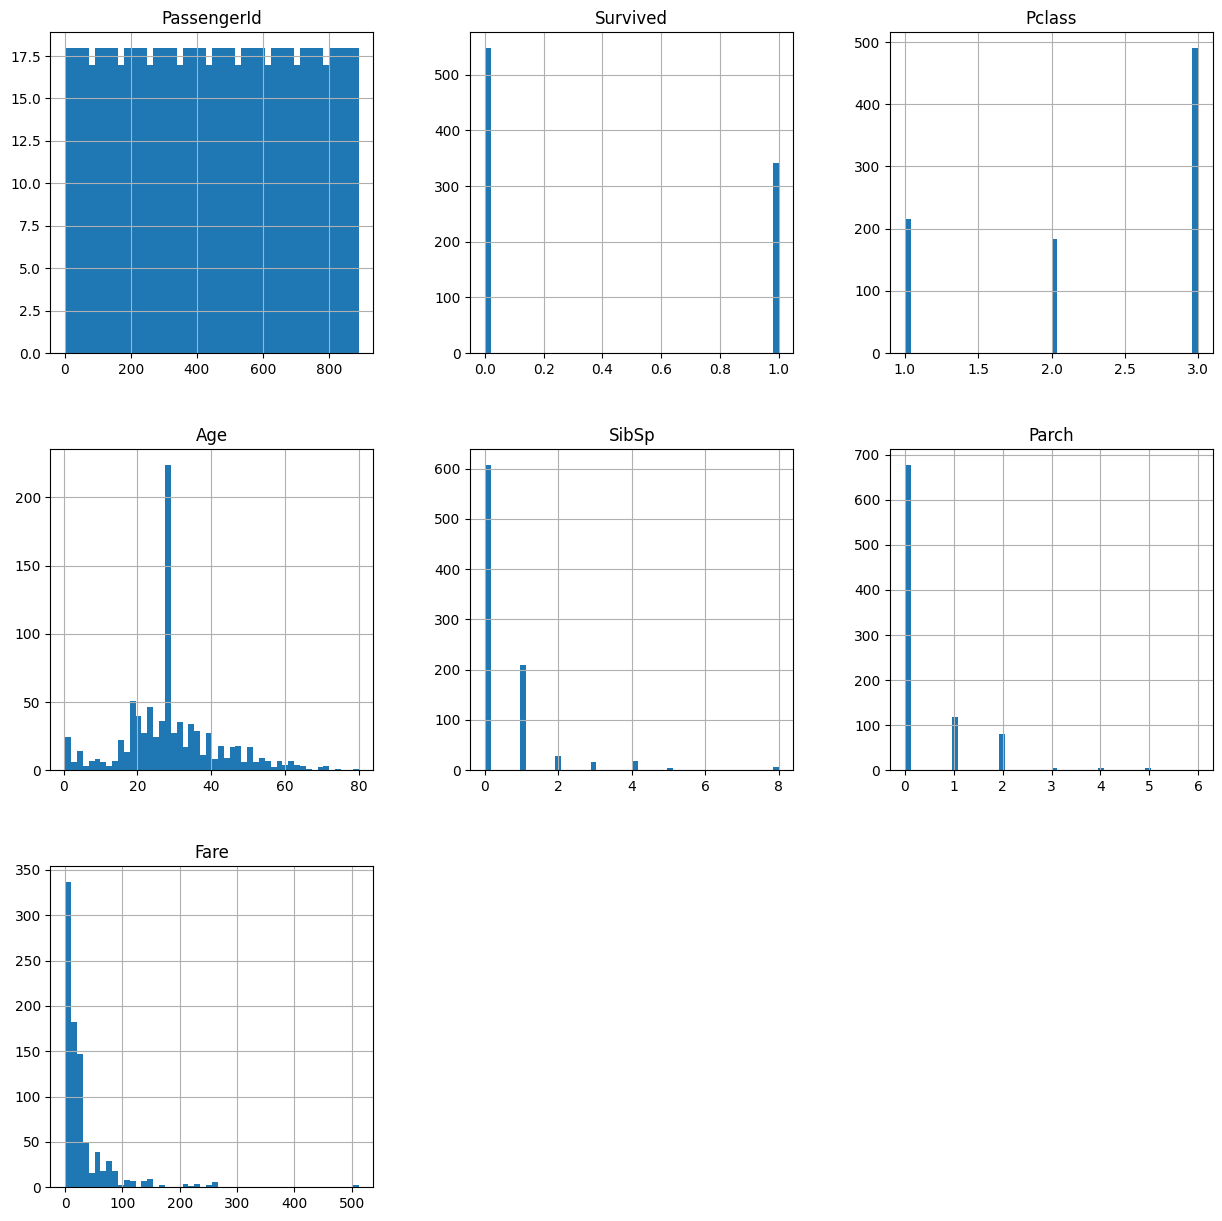

In [37]:
import matplotlib.pyplot as plt

train_df.hist(bins=50, figsize=(15, 15))
plt.show

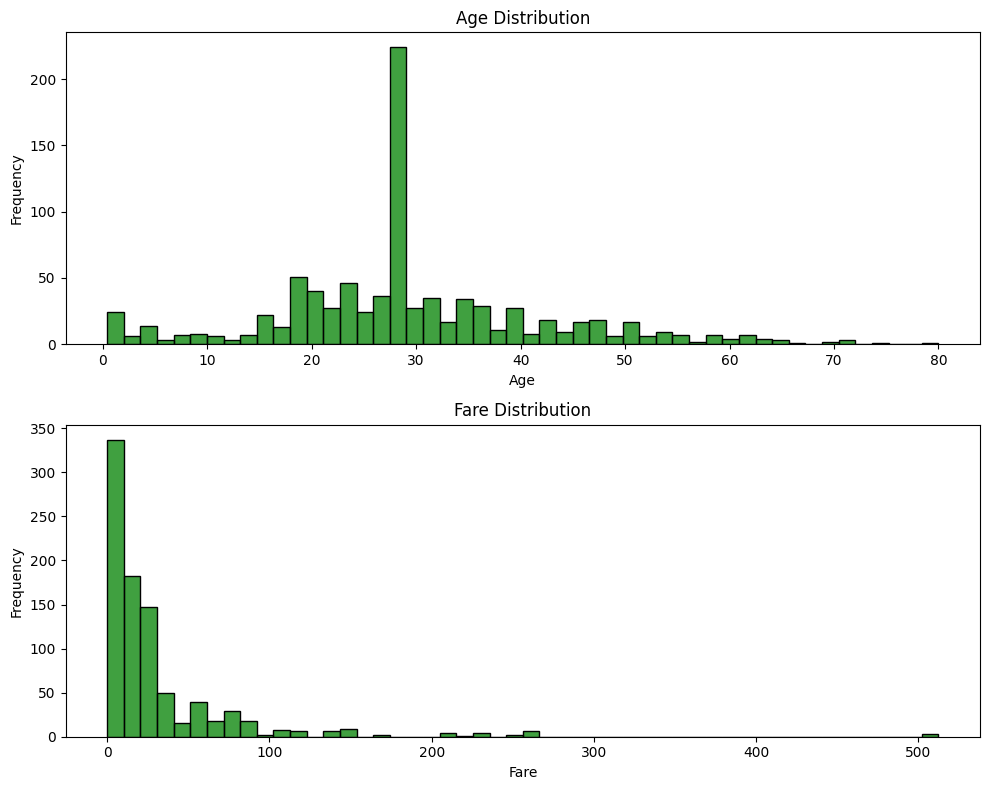

In [38]:
# Create the figure and axes
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))        #This creates 1 figure (fig) with 2 subplots (axes) stacked vertically (because nrows=2, ncols=1).


# Plot Age histogram
sns.histplot(train_df['Age'], bins=50, color="green", ax=axes[0])            # The first subplot (top)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Plot Fare histogram
sns.histplot(train_df['Fare'], bins=50, color="green", ax=axes[1])                 # The second subplot (bottom)
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

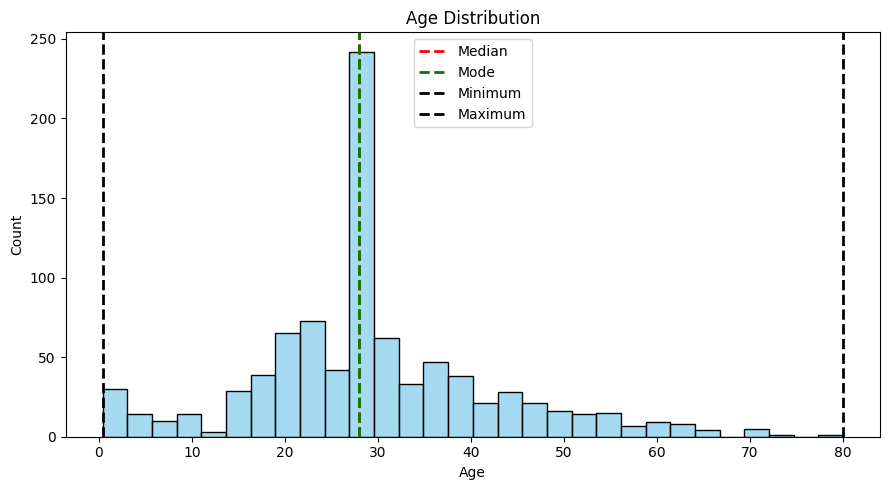

In [39]:
plt.figure(figsize=(9, 5))

# Plot Age histogram on the first subplot
sns.histplot(train_df['Age'], bins=30, color='skyblue')

# Add vertical lines for key statistics
plt.axvline(train_df['Age'].median(), color='red', linestyle='dashed', linewidth=2, label='Median')
plt.axvline(train_df['Age'].mode()[0], color='green', linestyle='dashed', linewidth=2, label='Mode')
plt.axvline(train_df['Age'].min(), color='black', linestyle='dashed', linewidth=2, label='Minimum')
plt.axvline(train_df['Age'].max(), color='black', linestyle='dashed', linewidth=2, label='Maximum')

# Show the legend
plt.legend()
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Adjust layout
plt.tight_layout()
plt.show()


# In the output, The Median Value and Mode Value are very close that's why  only one dotted line is visible.

Text(0.5, 0.98, 'Distribution of Age, SibSp, and Parch')

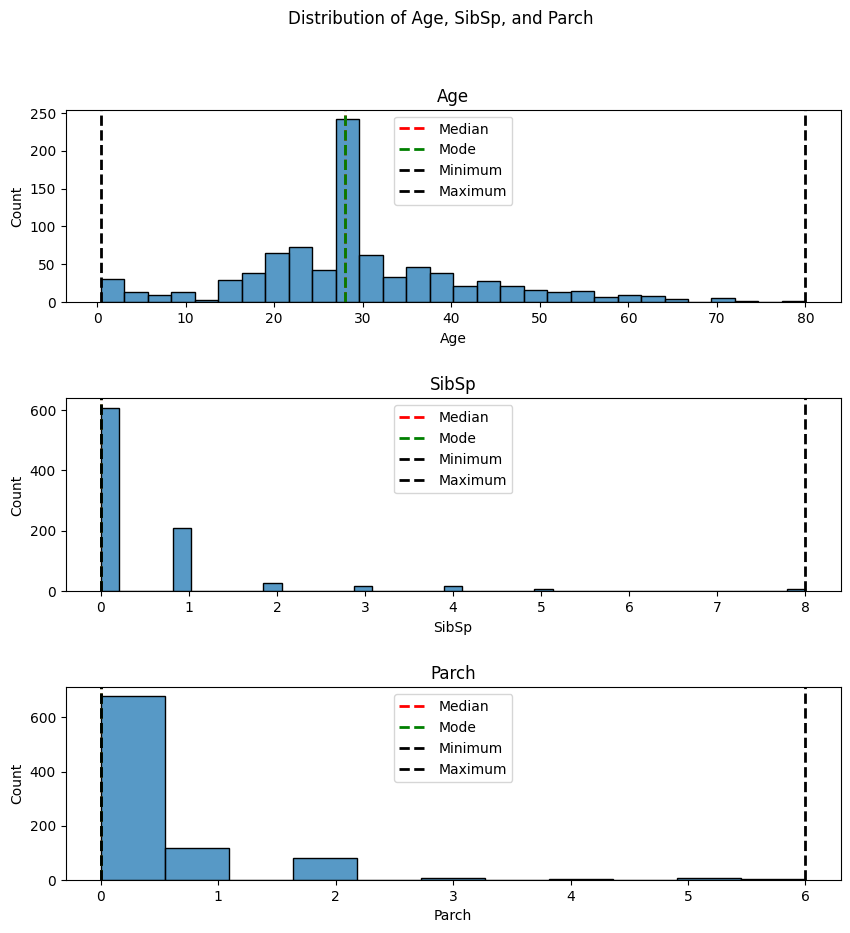

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=3, figsize=(10, 10))
sns.histplot(train_df['Age'], ax=axs[0])

axs[0].set_title('Age')
axs[0].axvline(train_df['Age'].median(), color='red', linestyle='dashed', linewidth=2, label='Median')
axs[0].axvline(train_df['Age'].mode()[0], color='green', linestyle='dashed', linewidth=2, label='Mode')
axs[0].axvline(train_df['Age'].min(), color='black', linestyle='dashed', linewidth=2, label='Minimum')
axs[0].axvline(train_df['Age'].max(), color='black', linestyle='dashed', linewidth=2, label='Maximum')
axs[0].legend(loc='upper center')                # Moves legend to the top-center


sns.histplot(train_df['SibSp'], ax=axs[1])

axs[1].set_title('SibSp')
axs[1].axvline(train_df['SibSp'].median(), color='red', linestyle='dashed', linewidth=2, label='Median')
axs[1].axvline(train_df['SibSp'].mode()[0], color='green', linestyle='dashed', linewidth=2, label='Mode')
axs[1].axvline(train_df['SibSp'].min(), color='black', linestyle='dashed', linewidth=2, label='Minimum')
axs[1].axvline(train_df['SibSp'].max(), color='black', linestyle='dashed', linewidth=2, label='Maximum')
axs[1].legend(loc='upper center')                   # Moves legend to the top-center


sns.histplot(train_df['Parch'], ax=axs[2])

axs[2].set_title('Parch')
axs[2].axvline(train_df['Parch'].median(), color='red', linestyle='dashed', linewidth=2, label='Median')
axs[2].axvline(train_df['Parch'].mode()[0], color='green', linestyle='dashed', linewidth=2, label='Mode')
axs[2].axvline(train_df['Parch'].min(), color='black', linestyle='dashed', linewidth=2, label='Minimum')
axs[2].axvline(train_df['Parch'].max(), color='black', linestyle='dashed', linewidth=2, label='Maximum')
axs[2].legend(loc='upper center')                  # Moves legend to the top-center


plt.subplots_adjust(hspace=0.5)                             # hspace increases vertical space
fig.suptitle('Distribution of Age, SibSp, and Parch')

In [41]:
print(train_df['SibSp'].median())
print(train_df['SibSp'].mode())
print(train_df['SibSp'].min())

# That's why in the SibSp and Parch graph, we are not able to see the median and mode lines as the value of median = mode = min = 0. That's why they appear as overlap.


0.0
0    0
Name: SibSp, dtype: int64
0


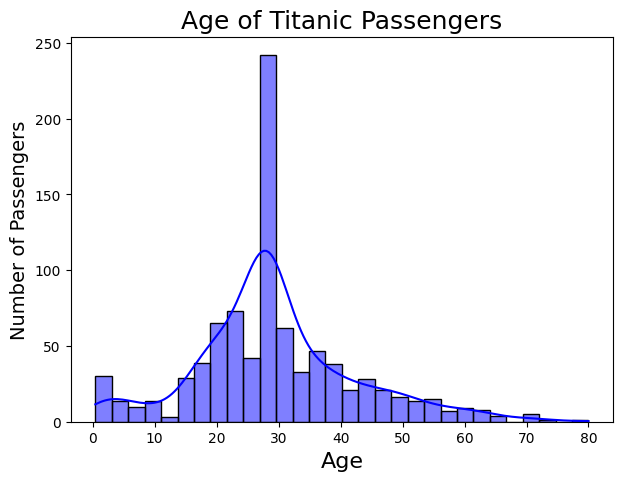

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(train_df['Age'], kde=True, color="blue", ax=ax)
ax.set_title('Age of Titanic Passengers', fontsize=18)
ax.set_xlabel('Age', fontsize=16)
ax.set_ylabel('Number of Passengers', fontsize=14)
ax.set_facecolor('none')

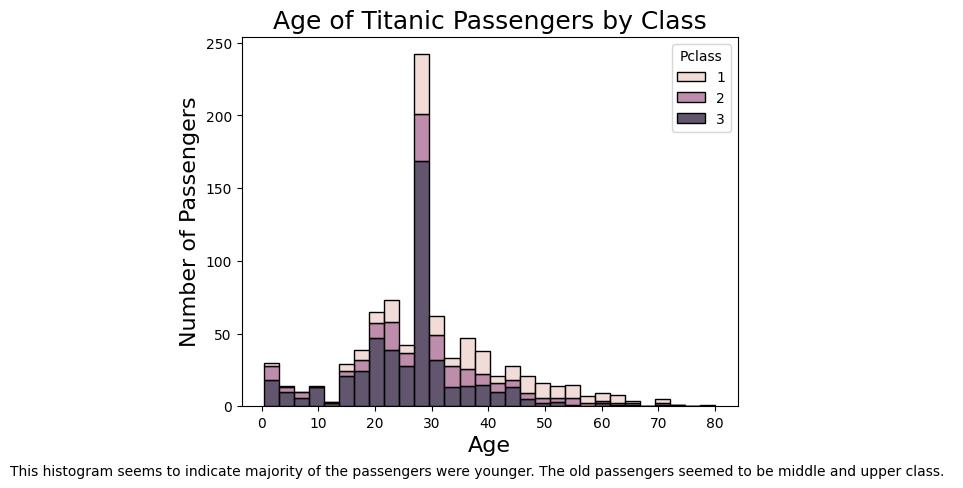

In [43]:
sns.histplot(train_df, x="Age", hue="Pclass", multiple='stack')        #The default approach to plotting multiple distributions is to “layer” them, but you can also “stack” them

plt.title('Age of Titanic Passengers by Class', fontsize=18)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Number of Passengers', fontsize=16)

# Add subtitle below the main title
plt.suptitle('This histogram seems to indicate majority of the passengers were younger. The old passengers seemed to be middle and upper class.  ', fontsize=10, y=-0.01)
plt.show()

In [44]:
train_df['Pclass'].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [45]:
import plotly.express as px

fig = px.histogram(
    train_df,
    x="Age",
    color="Sex",                 # Adds color based on gender (Sex). Similar to hue in seaborn
    nbins=8,                             # bins (bar groups). Same as bins=8. Fewer bins = wider bars, more bins = narrower bars.
    barmode="group",                                                # Same as multiple="dodge"
    title="Age of Titanic Passengers by Gender",
    labels={"Age": "Age", "count": "Number of Passengers"},
    width=900,
    height=400
)

fig.update_layout(
    xaxis_title="Age",
    yaxis_title="Number of Passengers",
    title_font_size=20,
    legend_title="Sex"
)

fig.show()


In [46]:
import plotly.express as px

# Create box plot -

# It shows:
# Median (center line)
# Quartiles (box edges)
# Minimum & Maximum (excluding outliers) (whiskers)
# Outliers (dots beyond whiskers)

fig = px.box(
    train_df,
    y="Age",
    title="Box Plot of Age"
)

# Customize layout
fig.update_layout(
    yaxis_title="Age (years)",
    legend_title_text = "",
    plot_bgcolor = "white",
    title_x=0.5,         # Center align title

)

fig.show()

# Use a boxplot when you want a quick, clean summary of your numeric data’s distribution, especially compared across groups, and to detect outliers.


C:\Users\Udit Patel\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning:

16.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\Udit Patel\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning:

20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\Udit Patel\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



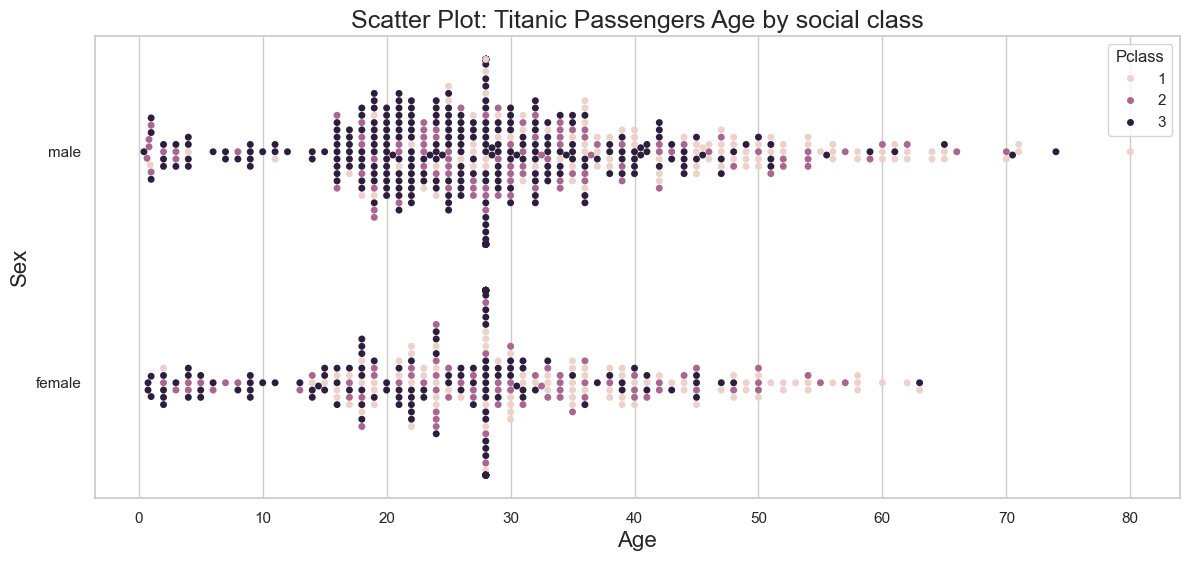

In [47]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(14,6))

# Draw a categorical scatterplot to show each observation
ax = sns.swarmplot(data=train_df, x="Age", y="Sex", hue="Pclass", size=5)
ax.set(ylabel="")

plt.title('Scatter Plot: Titanic Passengers Age by social class', fontsize=18)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Sex', fontsize=16)
plt.show()

C:\Users\Udit Patel\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning:

16.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\Udit Patel\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning:

20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\Udit Patel\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



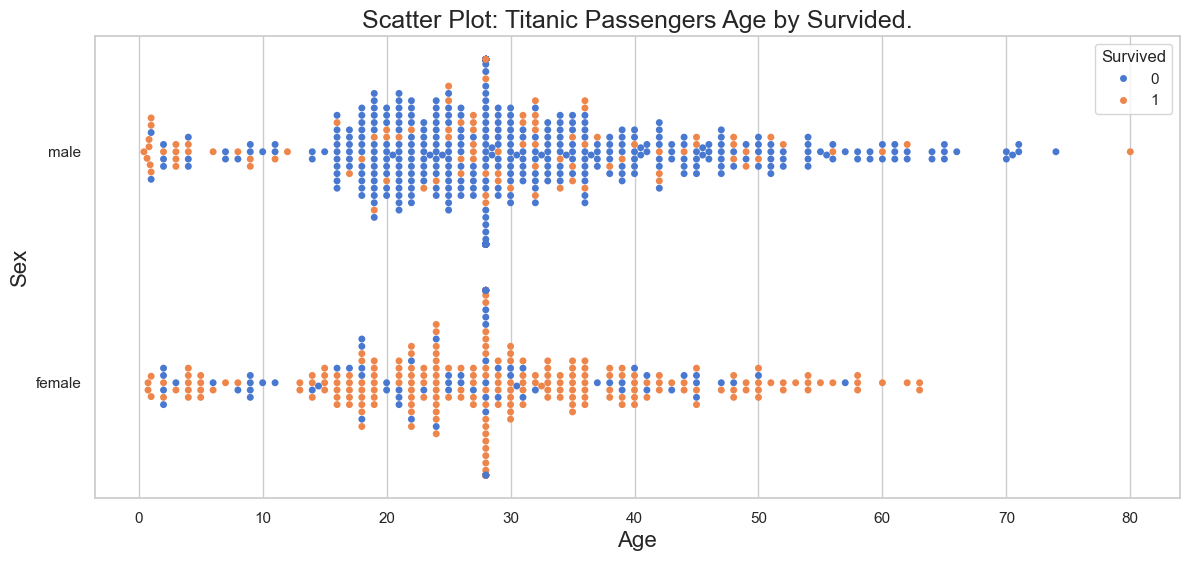

In [48]:

sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(14,6))

# Draw a categorical scatterplot to show each observation
ax = sns.swarmplot(data=train_df, x="Age", y="Sex", hue="Survived", size=5)
ax.set(ylabel="")

plt.title('Scatter Plot: Titanic Passengers Age by Survided.', fontsize=18)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Sex', fontsize=16)

plt.show()

# Correlation Matrix

In [49]:
corr_matrix = train_df.select_dtypes(include='number').corr()
corr_matrix["Age"].sort_values(ascending=False)


Age            1.000000
Fare           0.096688
PassengerId    0.034212
Survived      -0.064910
Parch         -0.172482
SibSp         -0.233296
Pclass        -0.339898
Name: Age, dtype: float64

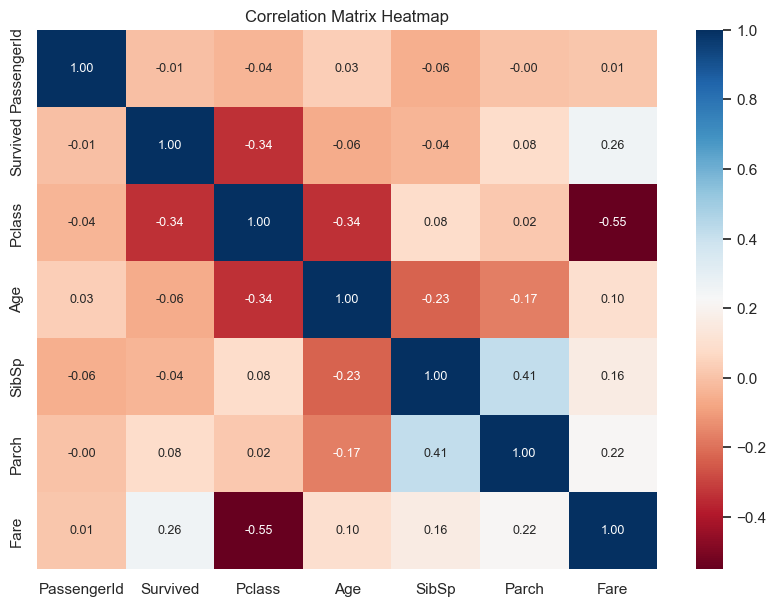

In [50]:
# This correlation heatmap (made with Plotly) shows how different numerical features in your dataset are linearly related to each other, using Pearson correlation coefficient (values from -1 to +1).

plt.figure(figsize=(10,7))                                            #to increase the size of the figure
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", annot_kws={'size': 9})
plt.title("Correlation Matrix Heatmap", loc="center")
plt.show()


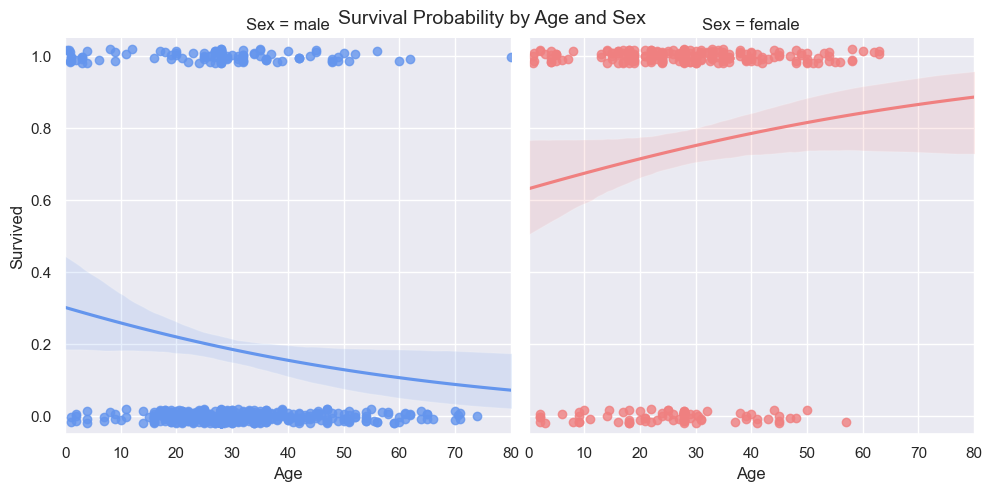

In [51]:
sns.set_theme(style="darkgrid")

# Make a custom palette with gendered colors
pal = dict(male="#6495ED", female="#F08080")

# Show the survival probability as a function of age and sex
g = sns.lmplot(
    x="Age", y="Survived", col="Sex", hue="Sex", data=train_df,            #Linear Model Plot- easy-to-use plotting function used to visualize linear relationships between variables.
    palette=pal, y_jitter=.02, logistic=True, truncate=False               #It plots scatter plots with an optional Regression line (like linear or logistic regression).
)

g.set(xlim=(0, 80), ylim=(-.05, 1.05))

# Set the figure title
g.fig.suptitle("Survival Probability by Age and Sex", fontsize=14)

# Show the plot
sns.despine()


# | `col="Sex"` | Creates **separate plots for each gender** (male/female) |
# | `hue="Sex"` | Colors the data points and line **based on gender** |
# | `y_jitter=.02` | Adds **vertical noise** to `Survived` values for better visualization (since it's binary 0 or 1) |
# | `logistic=True` | Fits a **logistic regression** curve (S-shaped) instead of a linear one |
# | `truncate=False` | Allows the regression line to extend to the full x-axis range, not just the data range |


In [52]:
print(train_df['Sex'].unique())
print(train_df['Sex'].head())
print(train_df['Sex'].isna().sum())

['male' 'female']
0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: object
0


In [53]:
# Check if you have original data
print(train_df['Sex'].unique())  # Should show ['male' 'female']


['male' 'female']


## Logistic regression
#### To perform a logistic regression for survival compared with sex and gender, you would need to follow these steps:

First, make sure your data is properly cleaned and prepared for analysis. This may involve removing missing values, transforming variables, or encoding categorical variables.

Next, select the variables you want to include in the model. In this case, you would select "Survived," "Sex," and "Pclass" (which indicates passenger class).

Use a statistical software package, such as Python, to fit the logistic regression model. In R, you can use the glm() function to fit a logistic regression model, while in Python, you can use the logistic regression function from the scikit-learn library.

Interpret the results of the logistic regression model. The coefficients for the "Sex" and "Pclass" variables will indicate the effect of these variables on the likelihood of survival, while the intercept term will represent the baseline probability of survival.

You can also evaluate the overall performance of the model using metrics such as accuracy, precision, and recall.

# Logistic Regression of the test data

#### Step 1: Convert Categorical Column to Numeric

In [54]:
import statsmodels.api as sm

# Conver 'Sex' variable to a binary variable (0 for male, 1 for female)
train_df['Sex_bin'] = pd.get_dummies(train_df['Sex'], drop_first=True)
test_df['Sex_bin'] = pd.get_dummies(test_df['Sex'], drop_first=True)


#What’s happening:
#Sex is a categorical variable ('male' or 'female').

#Machine learning models can’t directly work with text, so we convert it into binary (0 or 1).

#pd.get_dummies() converts categories to 0 and 1.

#drop_first=True drops the first category (e.g., "male"), so:
# drop_first=False ------>>>> This will create two separate columns for each category in 'Sex':

#Female → 1
#Male → 0

This code adds an intercept column to the test_titanic DataFrame using the sm.add_constant() function, and then makes predictions using the logistic regression model by passing the 'const' and 'Sex' columns of the test_titanic DataFrame to the predict() method. Remember that you need to specify the column names as a list when selecting the data, and include the 'const' column that was added by the sm.add_constant() function.

#### Step 2: Define X and Y for Training

In [55]:
# Fit the logistic regression model
X = train_df[['Sex_bin']].values
Y = train_df['Survived'].values

# What’s happening:
# X: Input features used to train the model (here, only 'Sex' column).
# y: Output label to be predicted ('Survived' → 1 = survived, 0 = not survived).
# .values is used to convert the pandas DataFrame/Series to NumPy arrays.

#### Step 3: Define X_test and Y_test for Testing

In [56]:
## As we had two tables, train and test, I needed to define the variables X_test and Y_test
X_test = test_df[['Sex_bin']].values
Y_test = test_df['Survived'].values

# X_test: Input features from test data.
# Y_test: Actual labels for comparison.

#### Step 4: Create and Train Logistic Regression Model

In [57]:
LogisticRegression_model = LogisticRegression(random_state=0)                # Logistic regression model
LogisticRegression_model.fit(X,Y)                                            ## train the model


# What’s happening:
# A logistic regression model is created from 'sklearn.linear_model.LogisticRegression'.
# random_state=0 ensures reproducible results.
# .fit(X, y) trains the model using training inputs and outputs.

LogisticRegression(random_state=0)

#### Step 5: Make Predictions

In [58]:
prediction = LogisticRegression_model.predict(X_test)                 #predict the response

# What’s happening:
# The model is used to make predictions on the test data (X_test).
# This returns an array of predicted values (0 or 1), representing whether the person survived or not.

#### Step 6: Evaluate Model with Confusion Matrix

In [59]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(Y_test,prediction)
print(confusion_matrix)


# What’s happening:
# Imports the confusion_matrix function to evaluate the model’s performance.

# Compares actual labels (y_test) and predicted labels (prediction).
# Outputs a matrix:
#                     [[266   0]                    # its a confusion-matrix...jo ki ye btati hai ki hamare model ne kitna sahi aur kitna galat predict kiyaa... here 0 means no error..
#                      [  0 152]]                                 # Works on Two values : Actual Values & Predicted Values.



[[266   0]
 [  0 152]]


In [60]:
# You are using this to evaluate how well your logistic regression model performed.

from sklearn.metrics import accuracy_score                                                       # accuracy_score = Total Correct Predictions / Total Predictions
from sklearn.metrics import precision_score                                                      #  precision_score = True Positives / (True Positives + False Positives)
print("Accuracy score: ",accuracy_score(Y_test,prediction))
print("Precision score: ", precision_score(Y_test, prediction, average='macro'))          # But since we have 2 classes (0 = not survived, 1 = survived), we calculate precision for both and then take the average.

# macro average = unweighted average
# It calculates precision for each class (0 and 1), then just takes the normal mean.
# Example:
# Precision for class 0 (not survived) = 0.95

# Precision for class 1 (survived) = 0.85

# Then macro (unweighted) average precision = (0.95 + 0.85) / 2 = 0.90

# Weighted average gives more importance to the bigger group (like class with more people).



# Output :
# Accuracy ----> 1.0 -----> Model predicted all outcomes (both 0 and 1) correctly
# Precision	-----> 1.0 -----> All predicted “survived” were actually correct (no false positives)

##this result goes in line with the logistic graph plotted - last graph.

Accuracy score:  1.0
Precision score:  1.0


### Logistic Regression, using train data and creating another test data from the train model

In [61]:
# Fit the logistic regression model into the train
X_all = pd.get_dummies(train_df[['Sex']], drop_first=True).values                                    # X_all - it is a feature - input variable / independent variable
# The double square brackets [['Sex']] make sure it's returned as a DataFrame, not a Series.
Y_all = train_df['Survived'].values                                                                  # Y_all - it is a label - output variable / dependent variable

In [62]:
# Slip the dataset titanic_train into a test
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, test_size = 0.25, random_state = 0)

# X_all ----->      All feature data (e.g. just 'Sex' column values)
# Y_all ----->      All label data (e.g. 'Survived' column values)
# test_size = 0.25	Use 25% of the data for testing and the rest (75%) for training
# random_state=0	Fixes the randomness so that every time you run the code, you get the same split. Useful for reproducibility.

In [63]:
LogisticRegression_model = LogisticRegression(random_state=0)          # Logistic regression model
LogisticRegression_model.fit(X_train,Y_train)                          # train the model

LogisticRegression(random_state=0)

In [64]:
#Predict on the test model
prediction = LogisticRegression_model.predict(X_test)

In [65]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(Y_test,prediction)
print(confusion_matrix)

# Our model correctly predicted 115 of the 140 who survided.
#The model also predicted 59 of the 84 not surviving cases and incorrectly predicted 25

[[115  24]
 [ 25  59]]


In [66]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
print("Accuracy score: ",accuracy_score(Y_test,prediction))
print("Precision score: ", precision_score(Y_test, prediction, average='macro'))

## The model predicted the outcomes correctly 78% of the time
##The model predicted a passenger to survive, it was correct 77% of the time.

Accuracy score:  0.7802690582959642
Precision score:  0.7661359724612736


### This result vary from the earlier result, because earlier we Trained & tested on same data but here we Split the data into train/test

# Naive Bayes Model -
### It Handles both Discrete And Continuous Data

In [67]:
train_df.loc[train_df['Pclass'] == 1]              # only those rows which were first class

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Sex_bin
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,False
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,E,True
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,C,False
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S,A,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,D,False
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,B,True
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,C,False
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B,False


In [68]:
## Transform a numerical varible into a categorical

# define the bins and labels for the categories
bins = [0, 1, 2, 3]
labels = ['First Class', 'Middle Class', 'Third Class']

# create a new column with the categorical variable
train_df['Pclass_Categories'] = pd.cut(train_df['Pclass'], bins=bins, labels=labels)

# print the updated DataFrame
print(train_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked     Deck  Sex_bin  \
0      0         A/5 21171   7.2500   NaN        S  Unknown     True   
1      0          PC 17599  71.2833   C85        C        C    False   
2      0  STON/O2. 3101282   7.9250   NaN        S  Unknown    False   
3      0            113803  53.1

In [69]:
train_df['Sex'] = pd.get_dummies(train_df['Sex'], drop_first=True).astype(int)
test_df['Sex'] = pd.get_dummies(test_df['Sex'], drop_first=True).astype(int)

In [70]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Sex_bin,Pclass_Categories
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,Unknown,True,Third Class
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,C,False,First Class
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Unknown,False,Third Class
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,C,False,First Class
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,Unknown,True,Third Class


In [71]:
train_df.index = train_df.iloc[:,0]                            # This sets the index of the DataFrame (train_df) to the values in the first column (column at index 0).
X_nvb = train_df.iloc [:, 2].values.reshape(-1, 1)            # Selects the 3rd column (iloc[:, 2]) of the DataFrame. and .reshape(-1, 1) converts it to a 2D shape, required for model input in sklearn.
Y_nvb = train_df.iloc[:, 1].values.reshape(-1, 1)                        # Selects the 2nd column (iloc[:, 1]) — likely the label or class.

In [72]:
#make an model object
gaussian_model = GaussianNB()

In [73]:
# Train the model
gaussian_model.fit(X_train, Y_train) # The model will be trained based on the 80% of data given

GaussianNB()

In [74]:
prediction = gaussian_model.predict(X_test)       # Predict the response

In [75]:
result = {'Survided':Y_test, 'pred':prediction}
result_df = pd.DataFrame(result)

In [76]:
from sklearn import metrics
print("Accuracy:", metrics.accuracy_score(Y_test, prediction))         # Checking NVB accuracy

Accuracy: 0.7802690582959642


# Decision Tree Model
### Fast, Efficient, and work with all kinds of data, both numerical and categorical ,discrete and continuous.

In [77]:
from sklearn.tree import DecisionTreeClassifier               # Train a decision tree model
from sklearn import preprocessing                             # Prepare and encode data - LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split          # Split data into training and testing sets - X_train, Y_train, X_test, Y_test
from sklearn import metrics                                   # Evaluate model predictions - confusion_matrix, accuracy_score, precision_score etc.

In [78]:
encoder = preprocessing.LabelEncoder()      # creating labelEncoder --->  it is used for labels/target(y)['Survived', yes/no]...while get_dummies is used for features/input(x)['Gender', 'Age','color'].

In [79]:
# Converting strings into numbers
PassengerId_encoded=encoder.fit_transform(train_df.iloc[:,0])
Survived_encoded=encoder.fit_transform(train_df.iloc[:,1])
Pclass_encoded=encoder.fit_transform(train_df.iloc[:,2])
Name_encoded=encoder.fit_transform(train_df.iloc[:,3])
Sex_encoded=encoder.fit_transform(train_df.iloc[:,4])
Age_encoded=encoder.fit_transform(train_df.iloc[:,5])
SibSp_encoded=encoder.fit_transform(train_df.iloc[:,6])
Parch_encoded=encoder.fit_transform(train_df.iloc[:,7])
Ticket_encoded=encoder.fit_transform(train_df.iloc[:,8])
Fare_encoded=encoder.fit_transform(train_df.iloc[:,9])
Cabin_encoded=encoder.fit_transform(train_df.iloc[:,10])
Embark_encoded=encoder.fit_transform(train_df.iloc[:,11])


# Here we don't need to encode every column because some columns may have numeric values and some columns may also have unique values...but for learning, i'm doing this in this way....

In [80]:
# Combining encoded data
train_df=list(zip(PassengerId_encoded,Survived_encoded,Pclass_encoded,Name_encoded,Sex_encoded,Age_encoded,SibSp_encoded,Parch_encoded,Ticket_encoded,Fare_encoded,Cabin_encoded,Embark_encoded))
train_df = pd.DataFrame(train_df, columns = ['PassengerId', 'Survided', 'Pclass', 'Name', 'Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embark'])
data_to_use = train_df.iloc[:, 2:11]  # Features
data_to_target = train_df.iloc[:,1]    # Output

# It combines all your encoded columns (like Age, Sex, Fare, etc.) into one big list.
# It turns that big list into a table (DataFrame) with column names.
# It picks only the important features (like class, age, fare) from column 2 to 10. This will be used to train the model.
# It picks the Survived column (who lived or died).This is what you want the model to predict.

In [81]:
print("X_Train size is:",X_train.shape)                      # contains the inputs used to train the model.
print("X_Test size is:",X_test.shape)                          # used to test the model’s accuracy on new/unseen data.
print("Y_train size is:",Y_train.shape)                     #  Shows how many labels (targets like Survived = 0 or 1) are in your training set.
print("Y_Test size is:",Y_test.shape)                          # Shows how many labels are in your test set.

X_Train size is: (668, 1)
X_Test size is: (223, 1)
Y_train size is: (668,)
Y_Test size is: (223,)


In [82]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [83]:
print("X_Train size is:",X_train.shape)
print("X_Test size is:",X_test.shape)
print("Y_train size is:",Y_train.shape)
print("Y_Test size is:",Y_test.shape)

X_Train size is: (712, 1)
X_Test size is: (179, 1)
Y_train size is: (668,)
Y_Test size is: (223,)


In [84]:
# Create default Decision Tree classifer object

# The Gini Index (or Gini Impurity) is a method used in Decision Trees to decide how to split the data at each step.
decisionTree_model_gini = DecisionTreeClassifier()

# DecisionTreeClassifier() --->	This is a machine learning algorithm that creates a tree-like structure to make decisions.
# decisionTree_model_gini --->	The name of the model you are creating. You can use this variable to train the model and make predictions later

In [85]:
# Use entropy criterion
decisionTree_model_entropy = DecisionTreeClassifier(criterion="entropy")

# Creates a Decision Tree Classifier model.
# It uses Entropy (not Gini) to decide how to split the data.
# The model is stored in the variable decisionTree_model_entropy.

In [86]:

# Use max depth of 3
decisionTree_model_depth3 = DecisionTreeClassifier(max_depth=3)

# Creates a Decision Tree model with a maximum depth of 3.
# The tree can only grow up to 3 levels (3 questions/decisions deep).
# Stored in variable decisionTree_model_depth.

# Max_depth - It controls how deep the tree can go (i.e., how many times it can split the data).

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Splitting the data together so that X_train and Y_train will have the same number of samples.

In [88]:
# Fit the trees
decisionTree_model_gini.fit(X_train,Y_train)       # This trains a Decision Tree Classifier using the Gini Index --> Gini measures the "impurity" or how mixed the classes are in a node.
decisionTree_model_entropy.fit(X_train,Y_train)     # This trains a Decision Tree Classifier using Entropy --> Entropy measures the amount of information (or disorder) in the data.
decisionTree_model_depth3.fit(X_train,Y_train)     # This trains a Decision Tree with a maximum depth of 3 (i.e., the tree will grow only 3 levels deep).

DecisionTreeClassifier(max_depth=3)

In [89]:
# Make prediction

#  The .predict() function is used to ask the model: "Based on what you learned from the training data, what are the predicted labels for this new (unseen) test data?"

y_pred_gini = decisionTree_model_gini.predict(X_test)        # This uses the Gini-based Decision Tree to predict labels for X_test. The output is saved in y_pred_gini — it will be an array like: [0, 1, 1, 0, 0, 1, ...]
y_pred_entropy = decisionTree_model_entropy.predict(X_test)   # This uses the Entropy-based Decision Tree to make predictions on the same test data. The result is stored in y_pred_entropy.
y_pred_depth3 = decisionTree_model_depth3.predict(X_test)  # This uses the max_depth = 3 Decision Tree model to predict. Because the tree is only 3 levels, it may generalize differently — maybe less accurate but less overfit.

In [90]:
print("Accuracy (gini):",metrics.accuracy_score(Y_test, y_pred_gini))          # Checks how many predictions made by the Gini model were correct.
print("Accuracy (entropy):",metrics.accuracy_score(Y_test, y_pred_entropy))         #  Checks accuracy of the Entropy-based decision tree model.
print("Accuracy (depth3):",metrics.accuracy_score(Y_test, y_pred_depth3))        # Checks accuracy of the depth-limited tree (max_depth=3).

Accuracy (gini): 0.7821229050279329
Accuracy (entropy): 0.7821229050279329
Accuracy (depth3): 0.7821229050279329


In [91]:
from sklearn.metrics import label_ranking_average_precision_score

y_true = np.array([[1, 0, 0], [0, 0, 1]])
y_score = np.array([[0.75, 0.5, 1], [1, 0.2, 0.1]])
label_ranking_average_precision_score(y_true, y_score)      # Calculates the Label Ranking Average Precision Score (LRAP), used in multi-label classification problems - Returns a value between 0.0 and 1.0

0.41666666666666663

### ----------------------------------------- Completion of the Project ----------------------------------------------